# Connectivity matrix for resting state

In [1]:
import sys
sys.path.insert(0, '../')

from src.load_data import PatientLoader #our data loader

import numpy as np
import matplotlib.pyplot as plt
from nilearn import datasets, image
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure
from nilearn import plotting
import os

## Only one patient without using NeuroFeatureExtractor

### Load packages and our data

For this example, we are going to use the data from patient sub-1004

In [2]:
file_path = "data/sub-1004"
loader = PatientLoader()
recording = loader.load(file_path)

### Dowload the atlas and adapt it for our data

In [3]:
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm', symmetric_split=True)
atlas_filename = atlas.maps

# we adapt the atlas to the fMRI data from patient 1004
atlas_native = image.resample_to_img(
    source_img=atlas_filename,
    target_img=recording.func.img,
    interpolation='nearest'  
)

[fetch_atlas_harvard_oxford] Dataset found in C:\Users\ainho\nilearn_data\fsl


C:\Users\ainho\AppData\Local\Temp\ipykernel_20068\3024645432.py:5: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  atlas_native = image.resample_to_img(
C:\Users\ainho\AppData\Local\Temp\ipykernel_20068\3024645432.py:5: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  atlas_native = image.resample_to_img(


### Region time series extraction

NiftiLabelsMasker function summarize brain signals from clusters that were obtained from the atlas.

In [4]:
labels_masker = NiftiLabelsMasker(
    labels_img=atlas_native,
    standardize="zscore",      
    detrend=True,
    low_pass=0.1,
    high_pass=0.01,
    t_r=recording.func.sampling_period,
    memory="nilearn_cache",
    memory_level=1,
    verbose=1
)

Extract time series. Time-series data is a dataset that tracks a sample over time and is collected regularly

In [5]:
region_time_series = labels_masker.fit_transform(recording.func.img)

[NiftiLabelsMasker.wrapped] loading data from Nifti1Image(
shape=(74, 74, 32),
affine=array([[ -2.97297287,   0.        ,  -0.        , 105.18074036],
       [ -0.        ,   2.97297287,  -0.        , -90.79684448],
       [  0.        ,   0.        ,   4.        , -48.42369843],
       [  0.        ,   0.        ,   0.        ,   1.        ]])
)


### Calculate connectivity matrix

In [6]:
connectivity_measure = ConnectivityMeasure(
    kind='correlation', 
    standardize="zscore"
)
connectivity_matrices = connectivity_measure.fit_transform([region_time_series])
matrix = connectivity_matrices[0]

### Ploting

It has a lot of adaptations because if not the visualization is messy because all the labels.

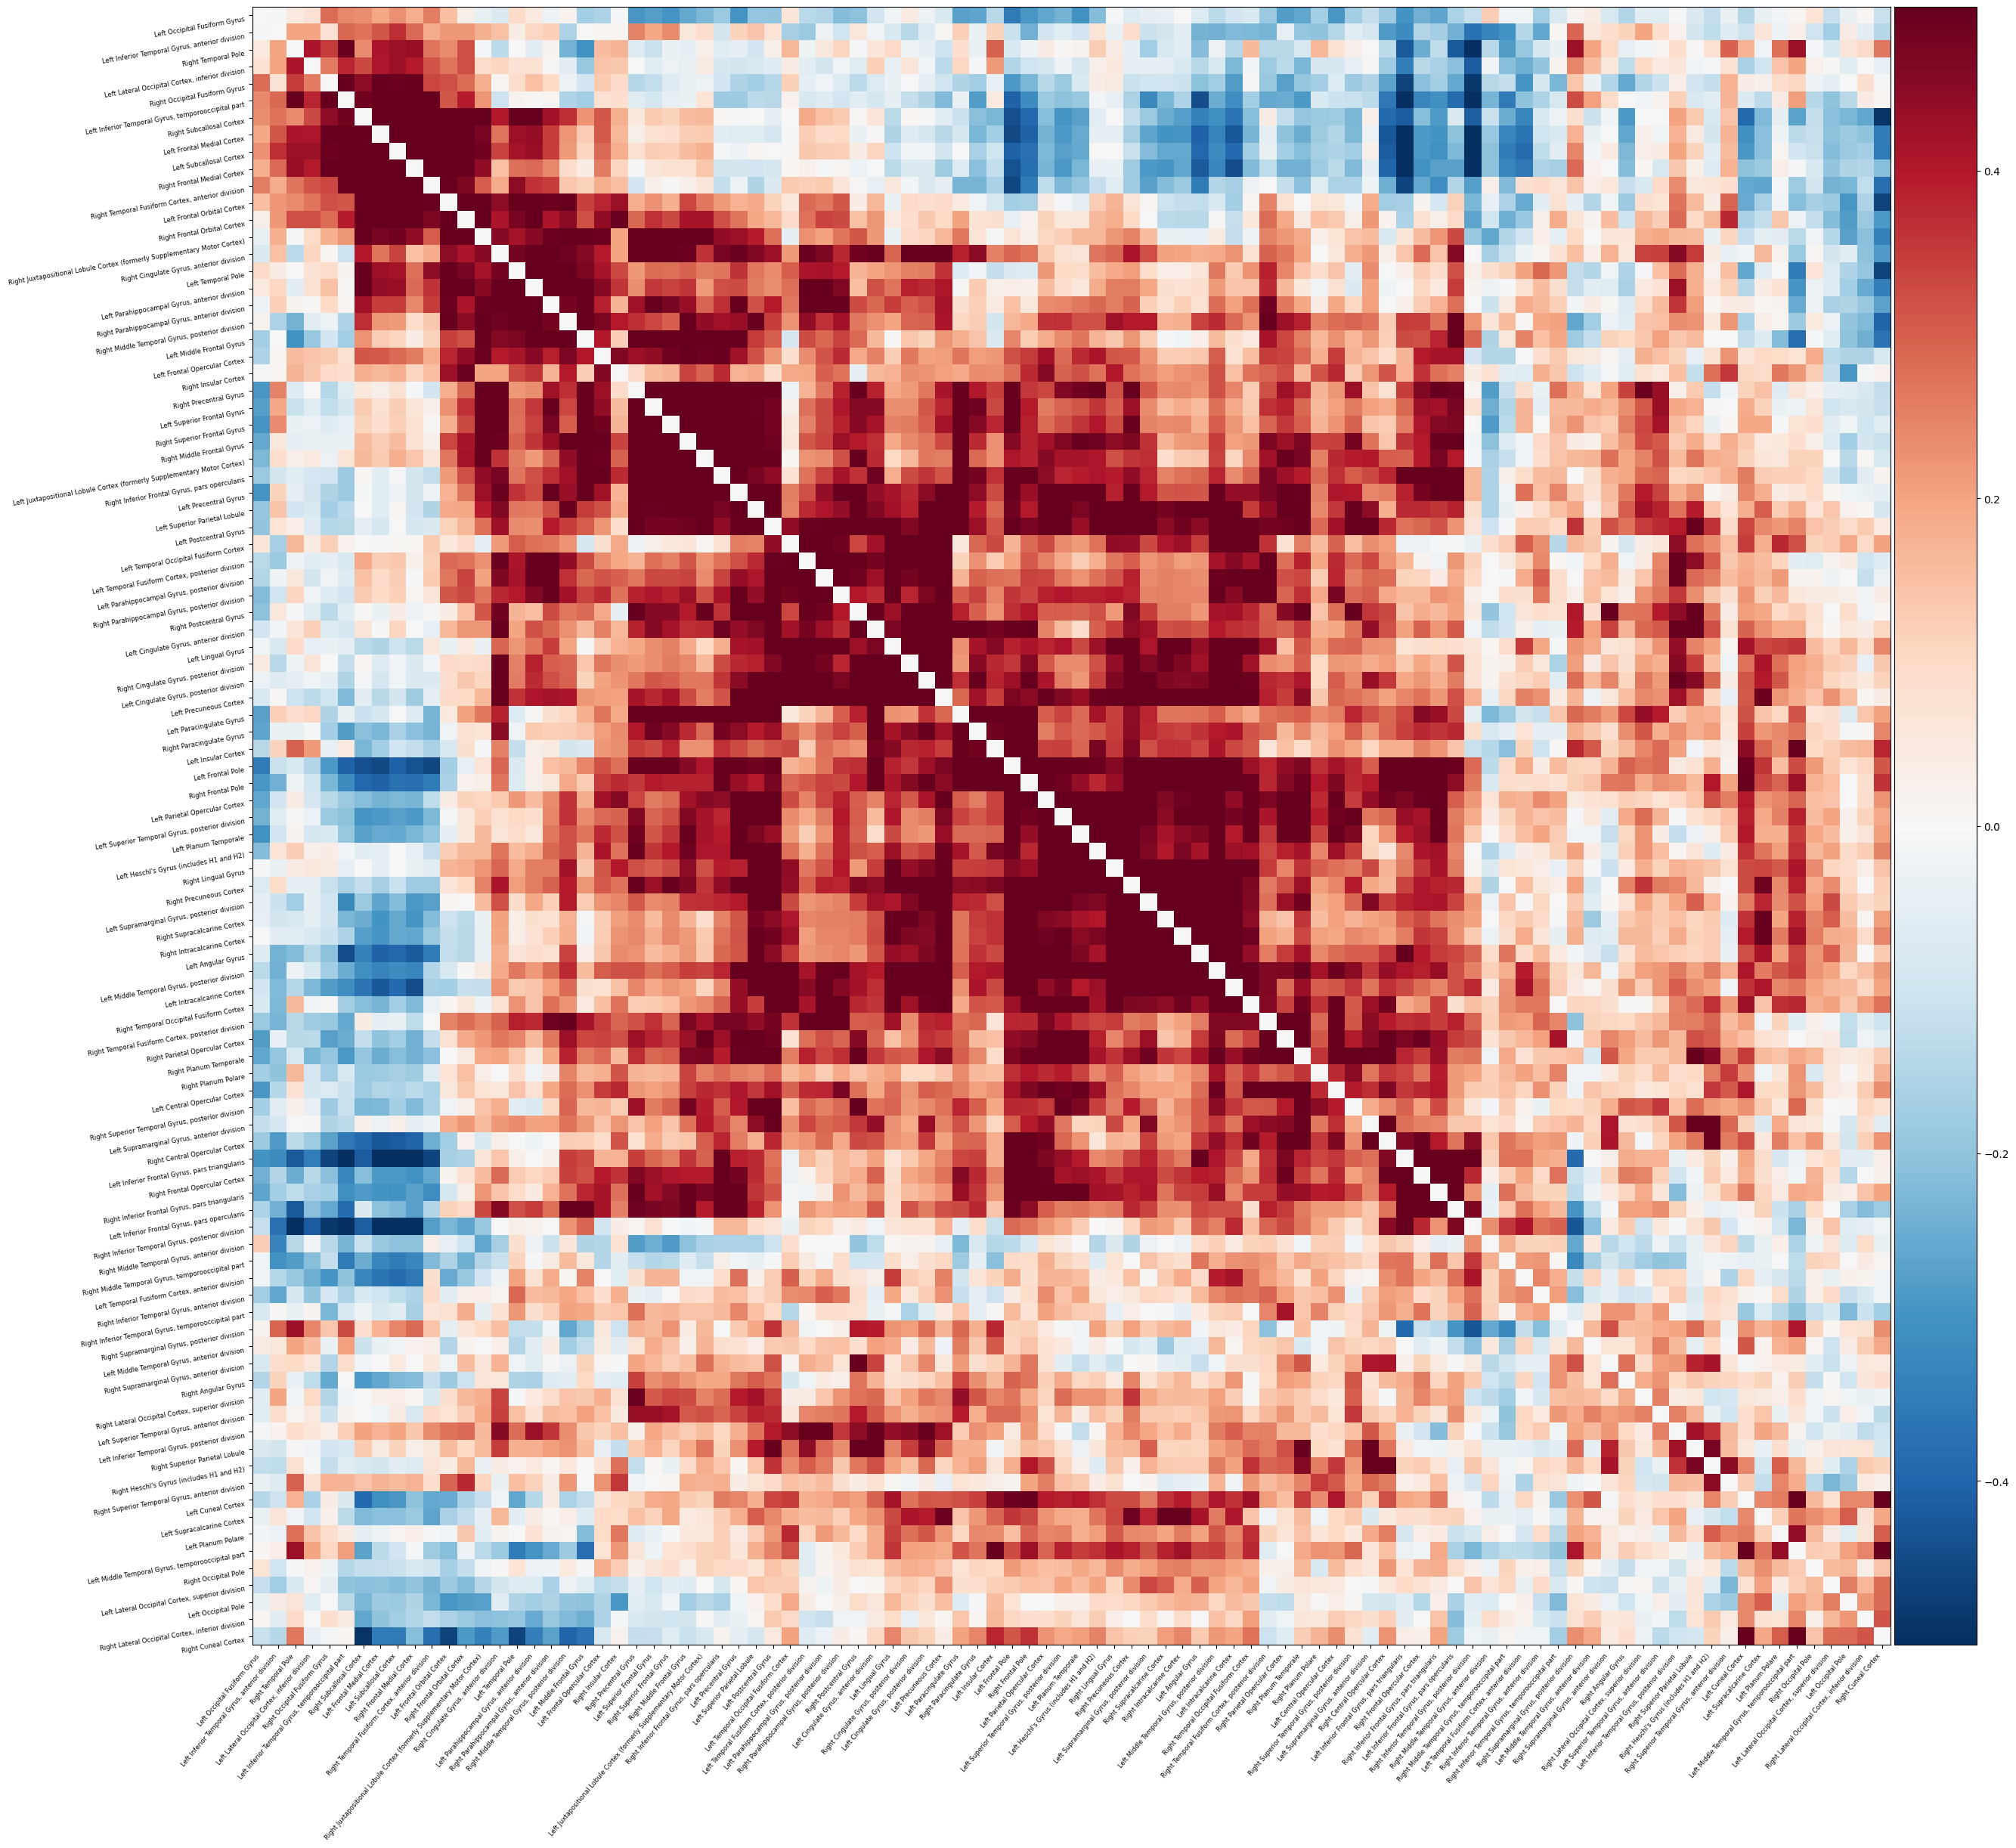

In [7]:
# Copy of the matrix because the diagonal will get putted to 0.
plot_matrix = matrix.copy()
np.fill_diagonal(plot_matrix, 0)

# We create a "gigant" canvas for plotting the image
fig, ax = plt.subplots(figsize=(26, 26))

# We plot the matrix
plotting.plot_matrix(
    plot_matrix,
    labels=atlas.labels[1:], # All the labels
    cmap='RdBu_r',           
    vmax=0.5,                
    vmin=-0.5,
    colorbar=True,
    reorder='average',       # Clustering jerárquico para agrupar las redes funcionales
    axes=ax                  
)

# Increase label size by defect
ax.tick_params(axis='both', labelsize=6)

# Rotate the labels for a more correct visualization
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Glass-Brain

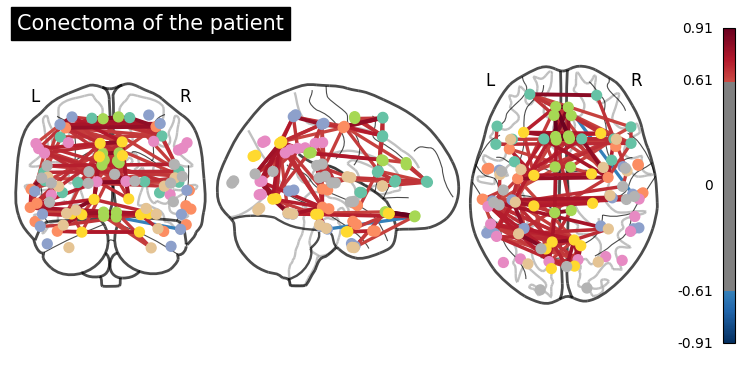

In [8]:
#Upload the labels
atlas_data = atlas_native.get_fdata()
present_ids = np.unique(atlas_data)
present_ids = present_ids[present_ids != 0].astype(int)


# Calculate the coordinates (in space MNI)
# 96 total coordinates
coords_mni_completas = plotting.find_parcellation_cut_coords(atlas_filename)

# We filt the coordinates
# We rest 1 because the present_ids goes from 1 to 96 but python intex goes from 0 to 95
coords_filtradas = coords_mni_completas[present_ids - 1]


# We plot the connectoma
plotting.plot_connectome(
    adjacency_matrix=matrix,         
    node_coords=coords_filtradas,
    edge_threshold='97%',               # To se how much connections
    title="Conectoma of the patient"
)

plotting.show()

As we are using 96 features, the visualization is not so much correct. For this reason, we are going to visualize only with the correlation matrix.

## Only one patient using NeuroFeatureExtractor

Now we are going to use the NeuroFeatureExtractor, that is a class created in Python by us for having a faster execution.

### Load NeuroFeatureExtractor

We will use the data extracted from the previous patient. The NeuroFeatureExtractor has all the methods required to do a pre-processing and to extract the features, but, in this case, we are only going to use the ones related to the correlation matrix.

In [23]:
from src.process import NeuroFeatureExtractor
from src.load_data import PatientLoader

extractor = NeuroFeatureExtractor() 


file_path = "data/sub-1004"
loader = PatientLoader()
recording = loader.load(file_path)

[fetch_atlas_harvard_oxford] Dataset found in C:\Users\ainho\nilearn_data\fsl


D:\Universidad\6 infierno de Dante\neuroimagen\projecto_git\project2\Neuroimage-FinalProjectCode\src\process.py:15: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  self.resampled_atlas = image.resample_img(
D:\Universidad\6 infierno de Dante\neuroimagen\projecto_git\project2\Neuroimage-FinalProjectCode\src\process.py:15: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  self.resampled_atlas = image.resample_img(


### Extract time series

We are using the same atlas than before. We dowload it in the init of NeuroFeatureExtractor.

In [24]:
time_series = extractor.extract_time_series(recording) 

[NiftiLabelsMasker.wrapped] Resampling images


D:\Programas\anaconda\envs\neuroimage\lib\site-packages\joblib\memory.py:326: UserWarning: Casting data from int16 to float32
  return self.func(*args, **kwargs)


### Extract Functional Connectivity

In [25]:
matrix = extractor.extract_functional_connectivity(time_series)

## Plotting

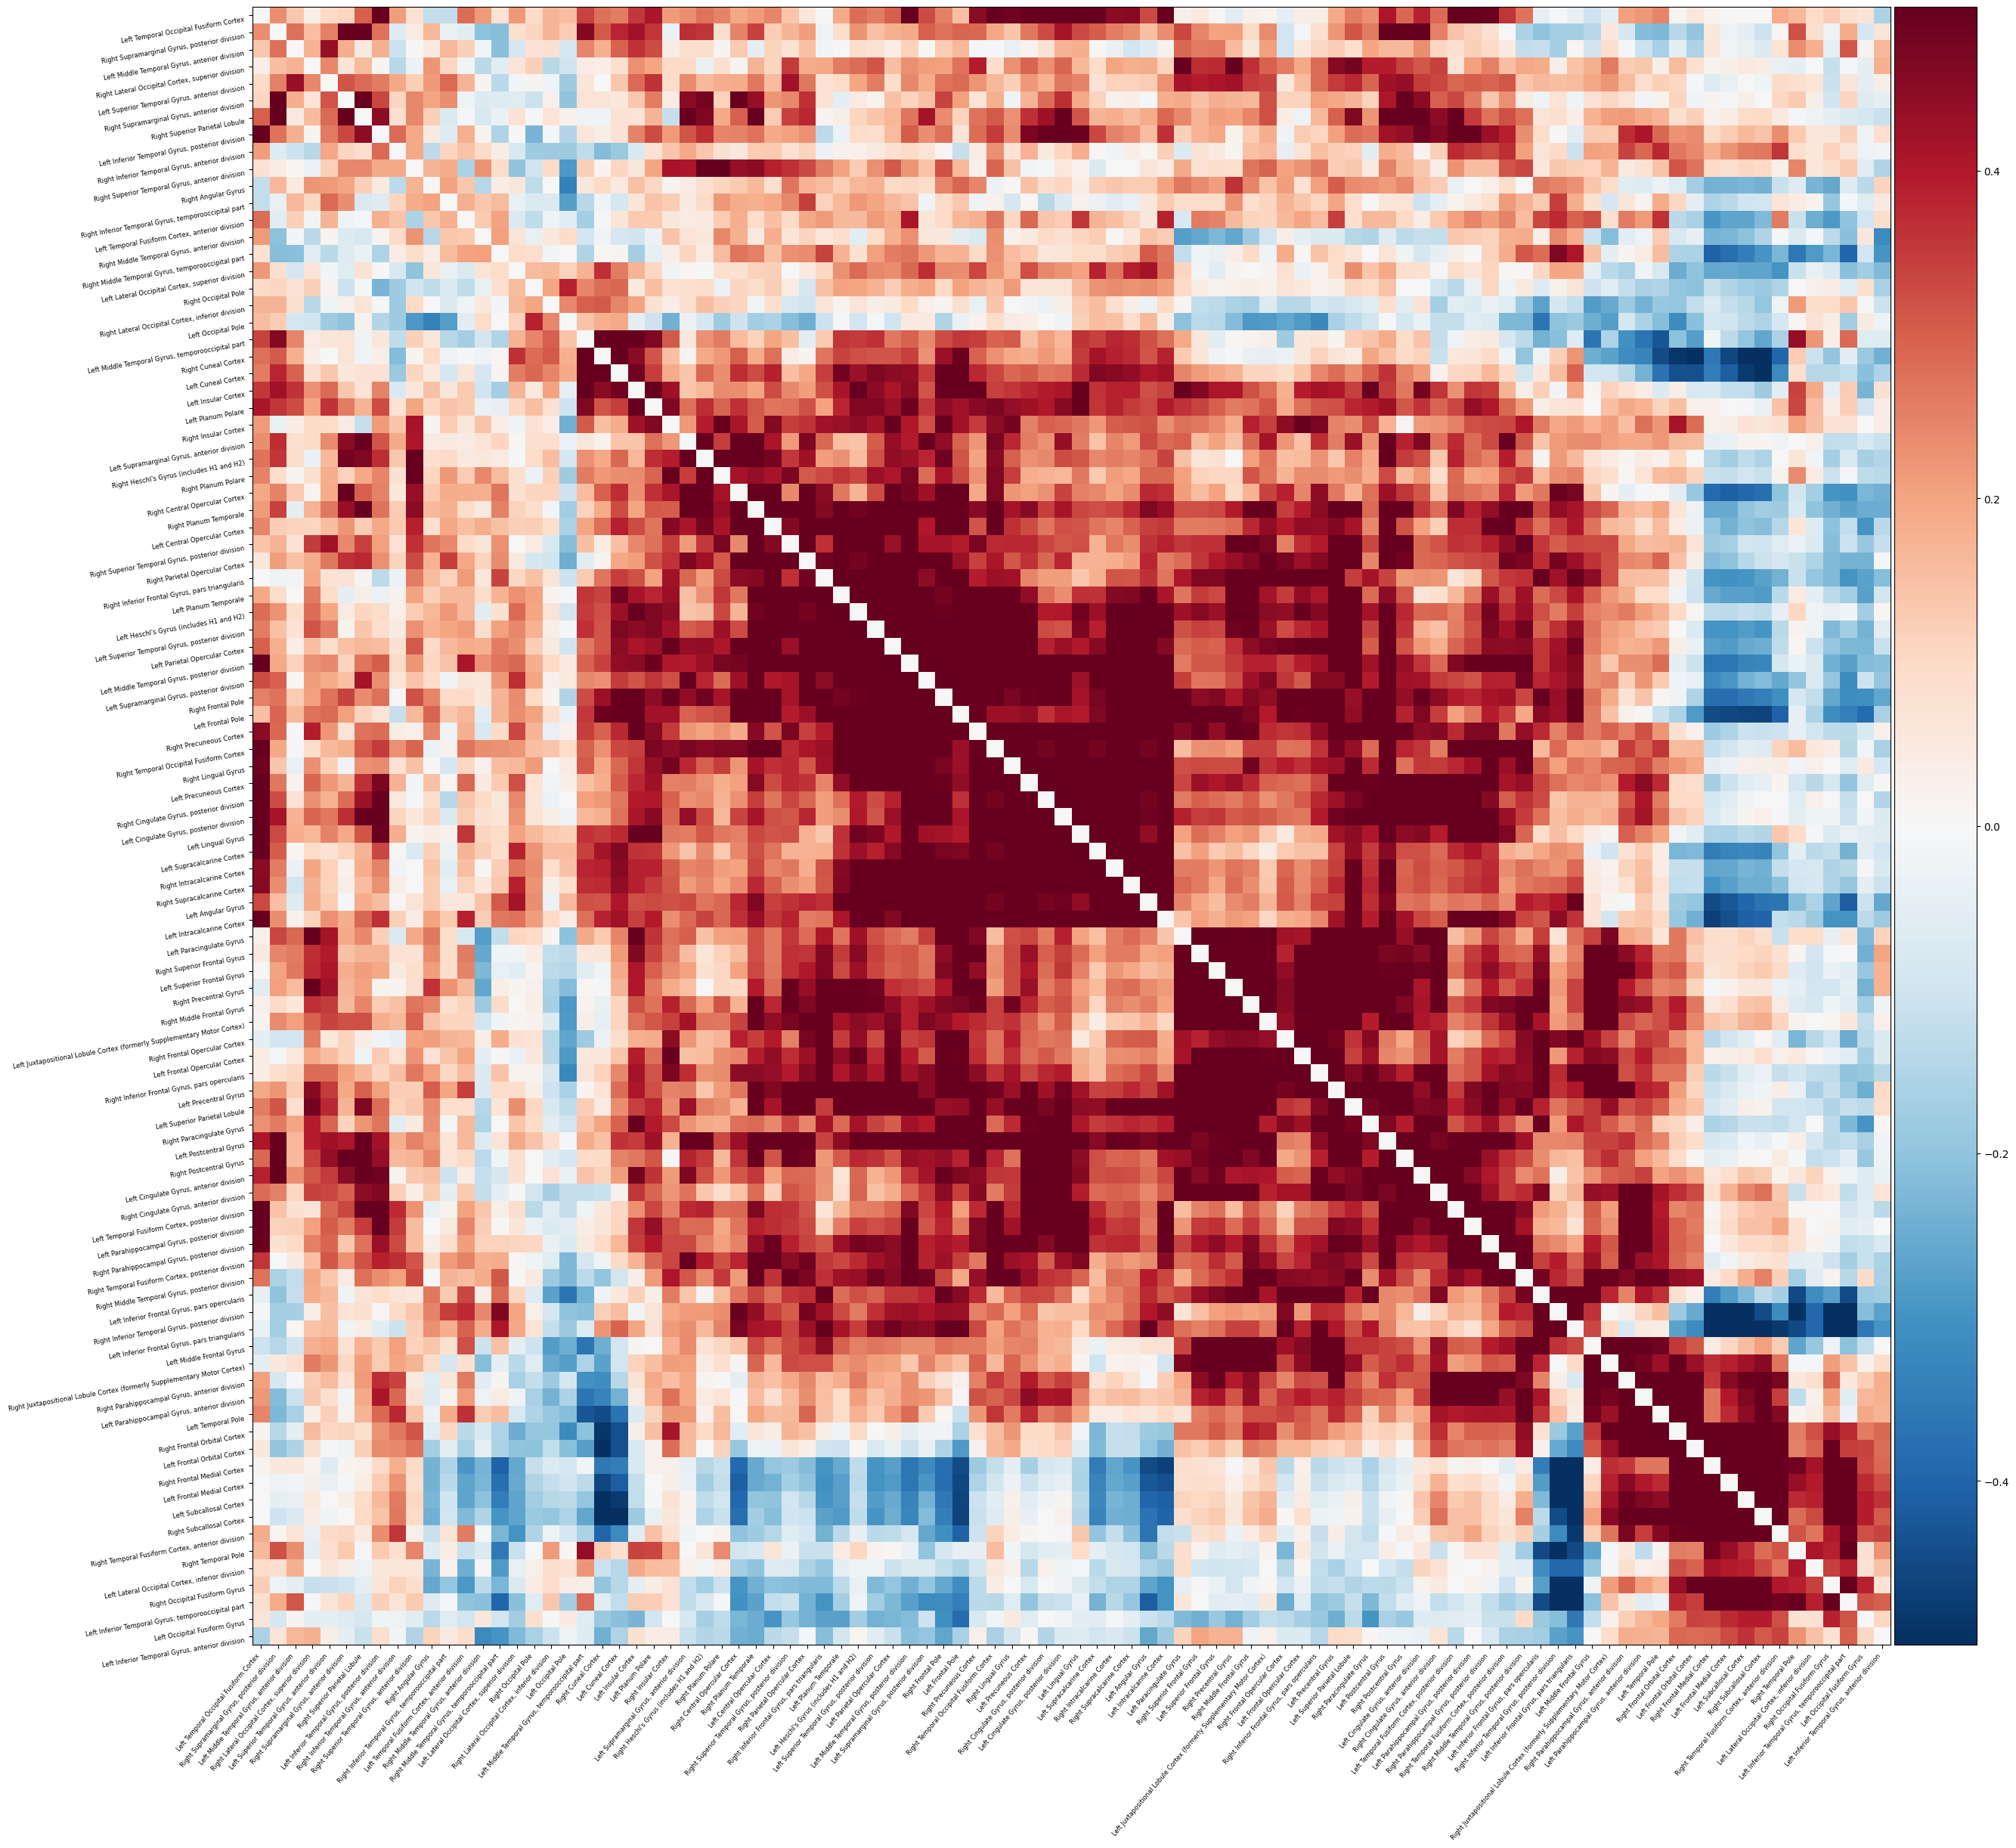

In [26]:
# Copy of the matrix because the diagonal will get putted to 0.
plot_matrix = matrix.copy()
np.fill_diagonal(plot_matrix, 0)

# We create a "gigant" canvas for plotting the image
fig, ax = plt.subplots(figsize=(26, 26))

# We plot the matrix
plotting.plot_matrix(
    plot_matrix,
    labels=atlas.labels[1:], # All the labels
    cmap='RdBu_r',           
    vmax=0.5,                
    vmin=-0.5,
    colorbar=True,
    reorder='average',       # Clustering jerárquico para agrupar las redes funcionales
    axes=ax                  
)

# Increase label size by defect
ax.tick_params(axis='both', labelsize=6)

# Rotate the labels for a more correct visualization
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig('foo.png')
plt.show()

It's seems like the matrix is different, but the results are the same. This difference is due to the reorder='average' parameter in the plot_matrix function that re-orders the matrix to create de "gropus" that we see in the plot of the correlation matrix.

Also, because in the NeuroFeatureExtractor class the atlas is forced to adapt to 3mm for make sure all the patients have the same atlas for the Masker process while in the initial method was adapted to the patient fMRI.

## Compare all patients. Young vs Adult

For doing that, we are going to use a loop that creates the connectivity matrix of all the patient files in the data/ folder and separate it if the patient is young or adult.

In [13]:
matrices_young = []
matrices_adult = []

#We move to the data/ folter
os.chdir("data")

# We do a loop to upload the files
for patient_dir in os.listdir("."):
    if not patient_dir.startswith("sub-"):
        continue

    print(f"Processing pacient: {patient_dir}...")
    patient_id = patient_dir.split('-')[1]
    
    #We use Try to avoid errors if one patient file is missing
    try:
        # Load the patient
        recording = loader.load(patient_dir)

        # Extraction of Time Series
        time_series = extractor.extract_time_series(recording)

        # Create the correlation matrix
        matrix = extractor.extract_functional_connectivity(time_series)

        #Separate if it's young or adult by the first number in the name
        if patient_id.startswith('1'):
            matrices_young.append(matrix)
        elif patient_id.startswith('2'):
            matrices_adult.append(matrix)
    
    except Exception as e:
        print(f"Error processing {patient_dir}: {e}")

# We return to the original folder
os.chdir("..")

print(f"\nProcessing done! Young: {len(matrices_young)} | Adults: {len(matrices_adult)}")

Processing pacient: sub-1004...
[NiftiLabelsMasker.wrapped] Resampling images


D:\Programas\anaconda\envs\neuroimage\lib\site-packages\joblib\memory.py:326: UserWarning: Casting data from int16 to float32
  return self.func(*args, **kwargs)


Processing pacient: sub-1005...
[NiftiLabelsMasker.wrapped] Resampling images


D:\Programas\anaconda\envs\neuroimage\lib\site-packages\joblib\memory.py:326: UserWarning: Casting data from int16 to float32
  return self.func(*args, **kwargs)


Processing pacient: sub-1006...
[NiftiLabelsMasker.wrapped] Resampling images


...

Processing pacient: sub-2037...
[NiftiLabelsMasker.wrapped] Resampling images


D:\Programas\anaconda\envs\neuroimage\lib\site-packages\joblib\memory.py:326: UserWarning: Casting data from int16 to float32
  return self.func(*args, **kwargs)


Processing pacient: sub-2038...
[NiftiLabelsMasker.wrapped] Resampling images


D:\Programas\anaconda\envs\neuroimage\lib\site-packages\joblib\memory.py:326: UserWarning: Casting data from int16 to float32
  return self.func(*args, **kwargs)



Processing done! Young: 34 | Adults: 28


### Ploting and compare results

Here we don't use the parameter reorder='average' to have the same distribution. Also, we don't use the labels right now to avoid an over saturated view.

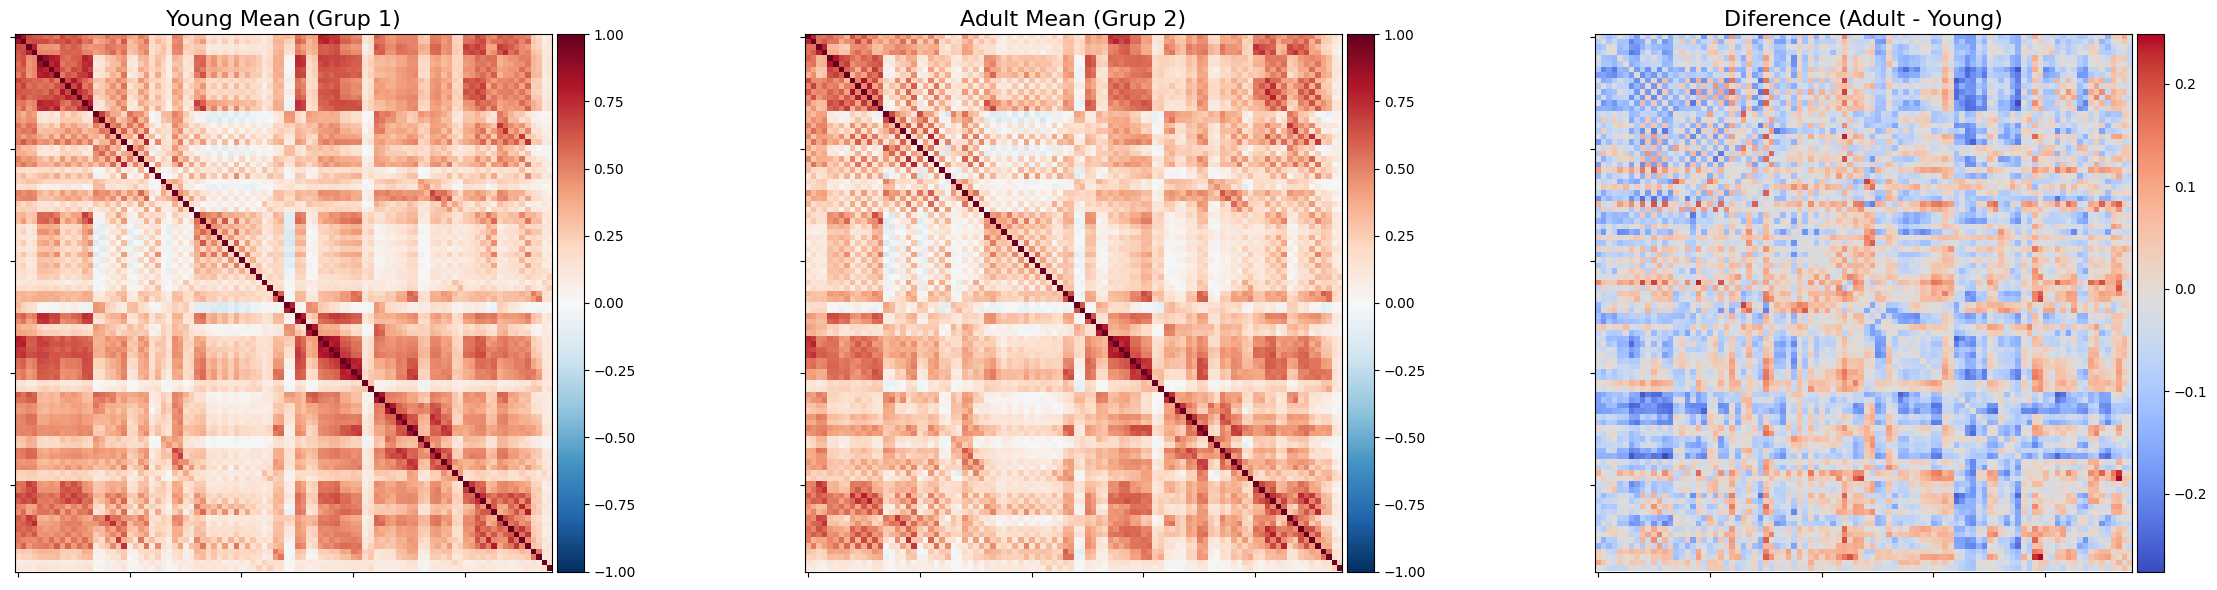

In [21]:
if len(matrices_young) > 0 and len(matrices_adult) > 0:
    mean_young = np.mean(matrices_young, axis=0)
    mean_adult = np.mean(matrices_adult, axis=0)
    matrix_diff = mean_adult - mean_young

    fig, axes = plt.subplots(1, 3, figsize=(24, 6))

    plotting.plot_matrix(mean_young, axes=axes[0], title="Young Mean (Grup 1)",
                         vmax=1, vmin=-1, cmap='RdBu_r', colorbar=True)

    plotting.plot_matrix(mean_adult, axes=axes[1], title="Adult Mean (Grup 2)",
                         vmax=1, vmin=-1, cmap='RdBu_r', colorbar=True)

    plotting.plot_matrix(matrix_diff, axes=axes[2], title="Diference (Adult - Young)",
                         cmap='coolwarm', colorbar=True)

    plt.tight_layout()
    plt.savefig('foo.png')
    plt.show()
else:
    print("Matrix can't be extracted.")

As result, it can be observed some differences in the connectivity with age. The "Difference (Adult - Young)" matrix highlights the functional connections that weaken with age (represented in blue), those that remain stable (in white), and those that strengthen over time (in red).

In [19]:
recording.anat.img

In [20]:
plt.savefig('foo.png')

<Figure size 640x480 with 0 Axes>